<a href="https://colab.research.google.com/github/Lucazere00/deep_learning/blob/main/weapons_detection_sam3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch==2.7.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

!wget https://github.com/Lucazere00/deep_learning/releases/download/dataset/dataset.zip

# 2. Scompattalo nella directory corrente
!unzip -q dataset.zip -d /content/dataset


Looking in indexes: https://download.pytorch.org/whl/cu126
--2026-01-15 13:20:26--  https://github.com/Lucazere00/deep_learning/releases/download/dataset/dataset.zip
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/1117631808/dba4f1b1-853b-483f-8e2d-b159e879db91?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-01-15T14%3A03%3A30Z&rscd=attachment%3B+filename%3Ddataset.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-01-15T13%3A02%3A51Z&ske=2026-01-15T14%3A03%3A30Z&sks=b&skv=2018-11-09&sig=FtEg7tFZtakicPrs%2F845WiZip8M3A4uWebw5xS6oOlg%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc2ODQ4Njc2NCwibmJmIj

In [ ]:
!git clone https://github.com/facebookresearch/sam3.git
%cd sam3
!pip install -e .

fatal: destination path 'sam3' already exists and is not an empty directory.
/content/sam3
Obtaining file:///content/sam3
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for sam3 (pyproject.toml) ... done
  Created wheel for sam3: filename=sam3-0.1.0-0.editable-py3-none-any.whl size=15368 sha256=491e0a1b1538f581ce1dfe6a5a3aa896c290b0b12b5d8b451345a8f21ae55f14
  Stored in directory: /tmp/pip-ephem-wheel-cache-4dlrvkn8/wheels/7c/90/be/80339bb9db8655024d6c9501da4e5efc6abbda4c897f5a6c43
Successfully built sam3
  Attempting uninstall: sam3
    Found existing installation: sam3 0.1.0
    Uninstalling sam3-0.1.0:
      Successfully uninstalled sam3-0.1.0


In [ ]:
# For running example notebooks
!pip install -e ".[notebooks]"

# For development
!pip install -e ".[train,dev]"

Obtaining file:///content/sam3
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 143.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.0/143.0 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.8/515.8 kB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 128.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 97.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 k

In [ ]:
from huggingface_hub import login
login()

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np

import sam3
from PIL import Image
from sam3 import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import plot_results


In [ ]:
!mkdir -p /content/sam3/assets/
!wget -P /content/sam3/assets/ https://github.com/openai/CLIP/raw/main/clip/bpe_simple_vocab_16e6.txt.gz

--2026-01-15 13:22:19--  https://github.com/openai/CLIP/raw/main/clip/bpe_simple_vocab_16e6.txt.gz
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/openai/CLIP/main/clip/bpe_simple_vocab_16e6.txt.gz [following]
--2026-01-15 13:22:19--  https://raw.githubusercontent.com/openai/CLIP/main/clip/bpe_simple_vocab_16e6.txt.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1356917 (1.3M) [application/octet-stream]
Saving to: ‘/content/sam3/assets/bpe_simple_vocab_16e6.txt.gz’

bpe_simple_vocab_16 100%[===================>]   1.29M  --.-KB/s    in 0.03s   

2026-01-15 13:22:19 (41.1 MB/s) - ‘/content/sam

In [ ]:
# Get SAM3 root path (parent directory of sam3 package)
sam3_root = os.path.join(os.path.dirname(sam3.__file__), "..")

# Load BPE vocabulary path
bpe_path = f"{sam3_root}/assets/bpe_simple_vocab_16e6.txt.gz"

# Build the SAM3 model
model = build_sam3_image_model(bpe_path=bpe_path)

# Create processor with confidence threshold
processor = Sam3Processor(model, confidence_threshold=0.5)


config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

sam3.pt:   0%|          | 0.00/3.45G [00:00<?, ?B/s]

In [ ]:
# Load your image (replace with your image path)
image_path = "/content/dataset/dataset/test/PNWsflgn8JU_30_60_000002_jpg.rf.6dbb829429d5f7444ea2395036a0eae3.jpg"
image = Image.open(image_path)

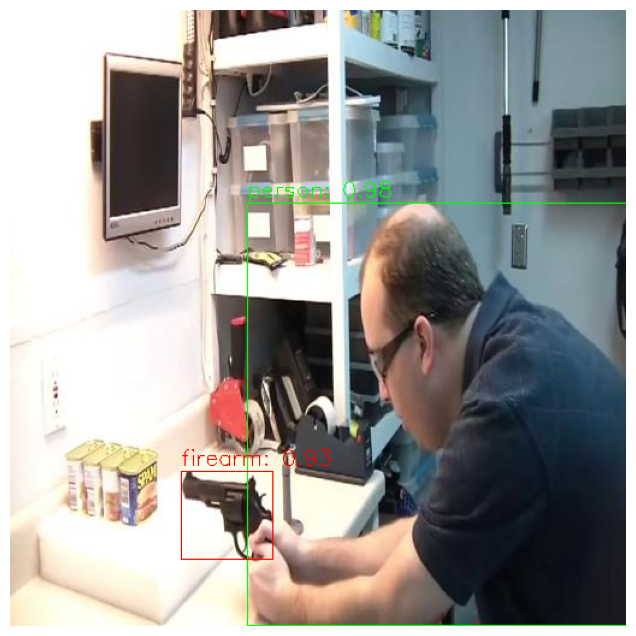

In [ ]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch

# Colori per le classi
CLASS_COLORS = {
    "person": (0, 255, 0),   # verde
    "firearm": (0, 0, 255)   # rosso
}

# Funzione per disegnare box
def draw_boxes(image, boxes, labels, scores):
    img = image.copy()
    for box, label, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = map(int, box)  # converti in interi
        color = CLASS_COLORS.get(label, (255, 255, 0))
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 1) # Changed thickness to 1
        cv2.putText(img, f"{label}: {score:.2f}", (x1, max(y1-5,0)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 1) # Changed thickness to 1
    return img

# -----------------------------
# Carica immagine
# -----------------------------
image_path = "/content/dataset/dataset/test/PNWsflgn8JU_30_60_000002_jpg.rf.6dbb829429d5f7444ea2395036a0eae3.jpg"
img_pil = Image.open(image_path).convert("RGB")
img_cv_for_drawing = np.array(img_pil)
img_cv_for_drawing = cv2.cvtColor(img_cv_for_drawing, cv2.COLOR_RGB2BGR)

all_boxes, all_scores, all_labels = [], [], []

# --- Inferenze separate per prompt ---
for cls in ["person", "firearm"]:
    inference_state = processor.set_image(img_pil)  # Pass the PIL image here
    processor.reset_all_prompts(inference_state)
    inference_state = processor.set_text_prompt(state=inference_state, prompt=cls)

    masks = inference_state.get("masks")    # [N,1,H,W] - non serve per box
    scores_cls = inference_state.get("scores")
    boxes_cls = inference_state.get("boxes")  # [N,4] già in pixel!

    # Filtra predizioni sotto soglia 0.3
    keep = scores_cls > 0.3
    if len(keep) > 0:
        boxes_cls = boxes_cls[keep].cpu().numpy()  # <-- converti in numpy
        scores_cls = scores_cls[keep].cpu().numpy()

        all_boxes.append(boxes_cls)
        all_scores.append(scores_cls)
        all_labels.extend([cls]*len(boxes_cls))

# Unisci tutto
if len(all_boxes) > 0:
    boxes = np.vstack(all_boxes)
    scores = np.hstack(all_scores)
else:
    boxes = np.zeros((0,4))
    scores = np.zeros((0,))

# -----------------------------
# Visualizza immagine con box
# -----------------------------
annotated_img = draw_boxes(img_cv_for_drawing, boxes, all_labels, scores)
annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,8))
plt.imshow(annotated_img_rgb)
plt.axis("off")
plt.show()

In [ ]:
import os
import json
import time
import numpy as np
import cv2
from PIL import Image
from tqdm import tqdm
import torch

# -----------------------------
# PARAMETRI
# -----------------------------
IMAGE_DIR = "/content/dataset/dataset/test"
OUTPUT_DIR = "/content/dataset/dataset/predictions_sam3"
ANNOTATED_DIR = os.path.join(OUTPUT_DIR, "annotated_images")
OUTPUT_JSON = os.path.join(OUTPUT_DIR, "sam3_test_predictions.json")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(ANNOTATED_DIR, exist_ok=True)

# Colori per classi
CLASS_COLORS = {
    "person": (0, 255, 0),   # verde
    "firearm": (0, 0, 255)   # rosso
}

# Mapping etichette per COCO
LABEL_TO_COCO = {
    "person": 1,
    "firearm": 2
}

# Funzione per disegnare box
def draw_boxes(image, boxes, labels, scores):
    img = image.copy()
    for box, label, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = map(int, box)
        color = CLASS_COLORS.get(label, (255, 255, 0))
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, f"{label}: {score:.2f}", (x1, max(y1-5,0)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    return img

# -----------------------------
# LOOP DI INFERENZA
# -----------------------------
predictions = []
times = []

image_files = sorted(os.listdir(IMAGE_DIR))

for img_name in tqdm(image_files, desc="Inferenza SAM3"):
    img_path = os.path.join(IMAGE_DIR, img_name)
    img_pil = Image.open(img_path).convert("RGB")
    img_cv = np.array(img_pil)
    img_cv = cv2.cvtColor(img_cv, cv2.COLOR_RGB2BGR)

    all_boxes, all_scores, all_labels = [], [], []

    start = time.time()
    for cls in ["person", "firearm"]:
        inference_state = processor.set_image(img_pil)
        processor.reset_all_prompts(inference_state)
        inference_state = processor.set_text_prompt(state=inference_state, prompt=cls)

        masks = inference_state.get("masks")
        scores_cls = inference_state.get("scores")
        boxes_cls = inference_state.get("boxes")  # [N,4] in pixel

        # Filtra predizioni sotto soglia 0.3
        keep = scores_cls > 0.3
        if len(keep) > 0:
            boxes_cls = boxes_cls[keep].cpu().numpy()
            scores_cls = scores_cls[keep].cpu().numpy()
            all_boxes.append(boxes_cls)
            all_scores.append(scores_cls)
            all_labels.extend([cls]*len(boxes_cls))

    infer_time = time.time() - start
    times.append(infer_time)

    if len(all_boxes) > 0:
        boxes = np.vstack(all_boxes)
        scores = np.hstack(all_scores)
    else:
        boxes = np.zeros((0,4))
        scores = np.zeros((0,))

    # --- Salvataggio predizioni JSON in formato COCO ---
    for box, label, score in zip(boxes, all_labels, scores):
        predictions.append({
            "image_name": img_name,
            "category_id": LABEL_TO_COCO[label],
            "bbox": [float(box[0]), float(box[1]), float(box[2]-box[0]), float(box[3]-box[1])],
            "score": float(score)
        })

    # --- Salvataggio immagine annotata ---
    annotated_img = draw_boxes(img_cv, boxes, all_labels, scores)
    save_path = os.path.join(ANNOTATED_DIR, img_name)
    cv2.imwrite(save_path, cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))

# -----------------------------
# Salvataggio JSON
# -----------------------------
with open(OUTPUT_JSON, "w") as f:
    json.dump(predictions, f, indent=2)

print(f"Inferenza completata su {len(image_files)} immagini")
print(f"Tempo medio: {sum(times)/len(times):.3f} s")
print(f"File JSON salvato in: {OUTPUT_JSON}")
print(f"Immagini annotate salvate in: {ANNOTATED_DIR}")


Inferenza SAM3: 100%|██████████| 500/500 [35:15<00:00,  4.23s/it]

Inferenza completata su 500 immagini
Tempo medio: 4.223 s
File JSON salvato in: /content/dataset/dataset/predictions_sam3/sam3_test_predictions.json
Immagini annotate salvate in: /content/dataset/dataset/predictions_sam3/annotated_images


In [ ]:
import json
from pycocotools.coco import COCO

GT_JSON = "/content/dataset/dataset/annotations/instances_test2017.json"
SAM3_JSON = "/content/dataset/dataset/predictions_sam3/sam3_test_predictions.json"
OUT_JSON = "/content/dataset/dataset/predictions_sam3/sam3_coco_predictions.json"

# carica coco GT
coco_gt = COCO(GT_JSON)

image_name_to_id = {
    img["file_name"]: img["id"]
    for img in coco_gt.dataset["images"]
}

with open(SAM3_JSON, "r") as f:
    sam3_preds = json.load(f)

coco_preds = []

for p in sam3_preds:
    if "image_name" not in p:
        continue

    image_name = p["image_name"]
    if image_name not in image_name_to_id:
        continue

    coco_preds.append({
        "image_id": image_name_to_id[image_name],
        "category_id": p["category_id"],      # firearm → weapon già mappato
        "bbox": p["bbox"],                    # [x, y, w, h]
        "score": p["score"]
    })

with open(OUT_JSON, "w") as f:
    json.dump(coco_preds, f)

print(f"Creato file COCO valido: {OUT_JSON}")


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Creato file COCO valido: /content/dataset/dataset/predictions_sam3/sam3_coco_predictions.json


In [ ]:
PRED_JSON = "/content/dataset/dataset/predictions_sam3/sam3_coco_predictions.json"

coco_gt = COCO(GT_JSON)
coco_pred = coco_gt.loadRes(PRED_JSON)

coco_eval = COCOeval(coco_gt, coco_pred, iouType='bbox')
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.31s).
Accumulating evaluation results...
DONE (t=0.06s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.814
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.883
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.835
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.517
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.532
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.909
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.682
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.807
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets